# **딥러닝 모델 템플릿**

<br>

### **TIPS 데이터 활용하여 쉽게 모델링하기**
- 간단하게 쉽게 딥러닝 모델링 만들어 보기
- 원하는 컬럼을 선택해서 회귀 모델, 분류 모델 만들어 보기
- 잘 몰라도 아래 순서에 맞게 , 이런식으로 실행하면 되겠구나 느끼기
- 여러분이 처음 한다고 생각하고 템플릿 작성함
- 백문이불여일타!! 반복 연습이 중요하다.

### **모델링 프로세스**
1. 데이터 가져오기
2. 데이터 분석
3. X , y 나누기
4. 딥러닝 모델링

<br>

## **0. tips2.csv 데이터 만들기**

In [ ]:
!pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

tips = sns.load_dataset('tips')

tips.sex.replace(['Female', 'Male'], [0,1], inplace=True)
tips.smoker.replace(['No', 'Yes'], [0,1], inplace=True)
tips.time.replace(['Dinner', 'Lunch'], [1,0], inplace=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
tips.day = le.fit_transform(tips.day)

tips.to_csv('tips2.csv', index=False)

<br>
<br>
<br>

---

## **1. 데이터 가져오기**
- 먼저, 데이터가 있어야 모델링을 만들수 있다.
- 데이터 가져오는 방법에는 여러가지 있다.
 - 본인 데이터를 직접 올리는 방법
 - 기존에 제공하는 데이터 가져다 쓰는 방법
- 반드시 데이터를 읽어와야 후속 작업을 할수 있다.

In [ ]:
# 필요한 라이브러리 가져오기
# 그냥 무조건 가져온다고 생각하자 : pandas, numpy, seaborn, matplotlib.pyplot
# seaborn 설치가 되어 있지 않으면 라이브러리는 설치 필요 : !pip install seaborn
!pip install seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#  판다스의 read_csv 함수를 찾았는데, 사용법을 모른다면
# 1. 아래와 같이 help 찾는다. ? , shift+Tab 2가지 방법으로 쥬피터 노트북에서 help을 볼수 있다.
# 2. 구글링 : pandas read_csv --> 판다스 사이트 접속해서 도움말 보기 : https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

pd.read_csv?

### TIPS 데이터셋 가져오기

In [ ]:
# tips2.csv 파일 읽고  tips2 데이터프레임에 저장합니다.

tips2 = pd.read_csv('tips2.csv')

In [ ]:
# head() 함수를 통해서 tips2 데이터프레임의 앞 5개 데이터를 확인 할수 있으며
# 인덱스와 컬럼들과 value값들로 구성됩니다.

tips2.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3
3,23.68,3.31,1,0,2,1,2
4,24.59,3.61,0,0,2,1,4


![tips](https://github.com/gzone1357/Image1/raw/main/git1.png)

---

## **2. 데이터 분석**
- 데이터 값이 어떻게 되어 있으며, 어떤 흐름을 보이는지, 다른 컬럼과의 관계는 어떤지를 파악하는 거다.
- 눈으로 데이터 수치를 보고 어떤 흐름인지 파악할수 있지만,
- 시각화를 통한다면 쉽게 흐름을 파악할수 있으니, 할수 있으면 사용해라.
- 여러분에게는 어려울수 있으니, 아, 이렇게 데이터를 가지고 시각화를 할수 있구나 느낀면 된다.


### **<font color=blue>하지만, 우리는 여기서는 데이터 분석을 하지 않아요.</font>**
### **<font color=red>데이터가 이미 정제되어 있어 머신러닝과 딥러닝 모델링에 집중하도록 할게요!!</font>**

<br>
<br>
<br>

---

## **3. [회귀모델 ] X, y 나누기**
- 지도학습 경우 데이터와 정답이 있어야 합니다.
- 데이터에 해당하는 X와 정답에 해당하는 y가 있어야 합니다.
- 아래와 같이 판다스를 이용하면 X, y를 쉽게 나눌수 있어요.
- X, y 데이터를 가지고 모델 학습하고 검증할수 있는 학습 데이터셋과 테스트 데이터셋으로 나눠 사용합니다.
- 그리고 레이블(y) 값을 보고 회귀 모델인지, 분류 모델인지 구별할수 있어요.
  - 레이블(y) : 학점 A/B/C/DF , 남녀 남/여, 숫자 0~9 --> 범주형으로 되어 있으면 분류 모델
  - 레이블(y) : 삼성전자 주가, 습도/온도, 유가동향등 --> 연속형으로 되어 있으면 회귀 모델

### **<font color=blue>우리는 회귀 모델을 만들어야 하는데, 어떤 컬럼을 정답(레이블, y)를 정할까요?</font>**
### **<font color=blue>회귀모델 위해서 연속형 컬럼을 레이블(y)로 선택해야 합니다.</font>**

In [ ]:
# tips2 데이터프레임의 뒤 5개 행 라인 보기
# 연속적인 값들이 있는 컬럼은 무엇이 있나요?

tips2.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,1,0,1,1,3
240,27.18,2.00,0,1,1,1,2
241,22.67,2.00,1,1,1,1,2
242,17.82,1.75,1,0,1,1,2
243,18.78,3.00,0,0,3,1,2


### **<font color=blue>연속적인 값을 나타내는 컬럼이 total_bill, tip 컬럼들이 있네요</font>**

In [ ]:
# 다시 한번 tips2 내용을 보겠습니다.

tips2.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3


### **그중에서 정답(레이블, y)을 tip 컬럼으로 정했고, tip의 값들이 연속적인 값이니 <font color=blue>회귀 모델</font>이 되겠네요.**

In [ ]:
# tips2 데이터프레임(테이블)에서 tip 컬럼만 제외하면 나머지가 X가 되겠네요.
# tips 컬럼을 제외하고 나머지 컬럼들을 일일히 리스트에 나열해 조회해 보겠습니다.

tips2[['total_bill', 'sex', 'smoker', 'day', 'time', 'size']]

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,1,2
1,10.34,1,0,2,1,3
2,21.01,1,0,2,1,3
3,23.68,1,0,2,1,2
4,24.59,0,0,2,1,4
...,...,...,...,...,...,...
239,29.03,1,0,1,1,3
240,27.18,0,1,1,1,2
241,22.67,1,1,1,1,2
242,17.82,1,0,1,1,2


In [ ]:
# 레이블(y)는 tips2 데이터프레임(테이블)에서 tip 컬럼만 가져오면 되겠네요.
# 출력 결과는 인덱스와 value값으로 이루어진 시리즈 형태입니다.

tips2['tip']

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

### **<font color=blue>판다스의 drop 함수를 이용하면 쉽게 X, y를 나눌수 있어요!!</font>**

In [ ]:
# ? 활용하여 도움말 보기

tips2.drop?

In [ ]:
# X 데이터 분리 : 판다스 drop 함수 활용
# 입력 : 'tip', axis=1

X = tips2.drop('tip', axis=1)

In [ ]:
# 분리된 X 데이터 확인 : 데이터 타입이 데이터프레임 확인
# 레이블 tip 컬럼은 보이지 않음을 확인할수 있습니다.

X

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,1,2
1,10.34,1,0,2,1,3
2,21.01,1,0,2,1,3
3,23.68,1,0,2,1,2
4,24.59,0,0,2,1,4
...,...,...,...,...,...,...
239,29.03,1,0,1,1,3
240,27.18,0,1,1,1,2
241,22.67,1,1,1,1,2
242,17.82,1,0,1,1,2


In [ ]:
# y 데이터 분리 : 'tip' 컬럼값만 분리해서 가져오면 됨.

y = tips2['tip']

In [ ]:
# 분리된 y 데이터 확인 : 데이터 타입이 Series 확인
# y 값이 실수형으로 되어 있음 확인

y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

### **X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 볼게요.**

In [ ]:
# X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 주는 train_test_split 함수가 있습니다.
# train_test_split 함수를 이용하면 쉽게 학습 데이터셋과 테스트 데이터셋 만들수 있습니다.
# 사이킷런의 train_test_split 함수 불러 옵니다.

from sklearn.model_selection import train_test_split

In [ ]:
# ? 활용하여 도움말 보기
train_test_split?

In [ ]:
# train_test_split 함수
# 1. X ,y 입력
# 2. test_size=0.2 --> train set : test set  = 8 : 2
# 3. random_state 사용하지 않으면 실행할때마다 학습셋과 테스트셋이 다르게 나와 고정하기 위해 사용
# 4. train_test_split 함수 결과로 X_train, X_test, y_train, y_test 나옴.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
# 학습 데이터셋과 테스트 데이터셋의 사이즈 확인

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [ ]:
# 뒤쪽에서 사용하게 편하게 데이터프레임을 넘파이(numpy)로 변경합니다.

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

<br>
<br>
<br>

---

<br>
<br>
<br>

![DNN](https://github.com/gzone1357/Image1/raw/main/DNN%EA%B5%AC%ED%98%84.png)

#### **먼저, 회귀 혹은 분류  결정**
+ 회귀 :
  - 삼성전자 주가 예측  >  아웃풋 동그라미 1개 , activation=None (혹은 linear)
  -  Loss 함수 : mse , mae
+ 분류 :
  - 남자,여자 예측 > 아웃풋 동그라미  1개 , activation=‘sigmoid’
  - 남자,여자 예측 >  아웃풋 동그라미  2개 이상 , activation=‘softmax’
  - 학점 A,B,C,D,F 예측 : 아웃풋 동그라미 5개 , activation=‘softmax’
  - Loss 함수 : 아웃풋 동그라미 1개 : binary_crossentropy
  - Loss 함수 : 아웃풋 동그라미 2개 이상 : sparse_categorical_crossentropy

---

## **4. (회귀) 딥러닝 모델링**

![DNN](https://github.com/gzone1357/Image1/raw/main/Deep-learning-8-i2tutorials.jpg)

### **1) 딥러닝 모델링 하기 위해, 제일 먼저 필요한 라이브러리 불러오기 입니다.**

In [ ]:
# 딥러닝 필요한 라이브러리 가져오기
# Sequential : 위의 전체 그림 레이아웃이라고 보시면 됩니다.
# Dense : 히든 레이어, 아웃풋 레이어을 가르키는 층으로 보시면 됩니다.
# EarlyStopping : callback으로 매 학습마다 성능을 측정하고 성능이 더 이상 나아지지 않으면 조기종료
# ModelCheckpoint : 주로 성능이 제일 좋을때 모델을 저장하는데 사용

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### **2) 전체 그림을 그릴수 있는 도화지 Sequential 정의합니다.**

In [ ]:
# 전체 그림을 그릴수 있는 도화지가 필요하듯이,
# 딥러닝 모델을 만들기 위한 Sequential 함수를 정의하여 model 이름으로 저장합니다.

model = Sequential()

### **3) 도화지를 채우기전에 입력과 출력을 고려해 봅시다.**

In [ ]:
# 입력 레이어에서 받아들여야 할 입력 갯수는 얼마일까요? X의 컬럼의 갯수만큼이 입력으로 들어가겠죠.
# 출력 레이어에서 출력으로 나가야할 갯수는 얼마일까요? 회귀모델이며, tip(y) 값이 예측하면 되겠죠.
# X_train.shape, y_train.shape 출력해 보자

print(X_train.shape)
print(y_train.shape)

(195, 6)
(195,)


### **4) 도화지에 우리가 필요한만큼의 레이어를 만들수 있으며 먼저 1개의 레이어 만들어 봅시다.**

In [ ]:
# 첫번째 레이어 즉, 첫번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 4개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 첫번째 히든 레이어는 입력을 꼭, 받아야 합니다. 몇개의 입력을 받을지 모델에게 알려 주어야 합니다.

model.add(  Dense( 4, activation='relu', input_shape=(6,)  )  )

### **5) 도화지에 1개의 레이어를 추가해 볼게요.**

In [ ]:
# 두번째 레이어 즉, 두번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 4개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 두번째 히든 레이어부터는 입력을 몇개 받을지 모델에게 알려줄 필요가 없어요. 알아서 계산하기 때문입니다.

model.add(  Dense(  4, activation='relu',  )  )

### **6) 도화지에 출력 레이어를 추가해 봅시다.**

In [ ]:
# 세번째 레이어 즉, 세번째 히든레이어(Dense Layer)로 마지막 레이어이기에 아웃풋 레이어 됩니다.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 아웃풋 레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 1개의 출력이므로 1개 동그라미 그립시다.
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 회귀 모델이기에 활성화 함수를 None (혹은 linear) 으로 지정합니다.

model.add(  Dense(  1, activation=None,  )  )

### **7) 도화지에서 그려진 전체 그림을 보겠습니다.**

In [ ]:
# summary() 함수를 사용해서 전체 레이아웃을 봅니다.

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4)                 28        
                                                                 
 dense_1 (Dense)             (None, 4)                 20        
                                                                 
 dense_2 (Dense)             (None, 1)                 5         
                                                                 
Total params: 53 (212.00 Byte)
Trainable params: 53 (212.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### **8) 도화지에서 그려진 전체 그림을 한꺼번에 그려보면**

In [ ]:
# Sequential 모델 만들기 --> model 변수 저장
# input layer : (6, )
# hidden layer : 4 unit , activation='relu'
# hidden layer : 4 unit , activation='relu'
# output layer : 1 unit , activation=None

model = Sequential()
model.add(  Dense( 4, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation=None  )  )

### **9) 도화지에서 그려진 그림을 컴퓨터가 이해해서 성능 좋은 모델을 만들어 보겠습니다.**

In [ ]:
# 모델 컴파일 : compile > 컴퓨터가 좋은 성능의 모델이 될수 있도록 여러가지 옵션을 설정해야 합니다.
# 회귀 모델 loss : mse, mae > 우리는 loss='mse' 사용하겠습니다.
# 최적화 알고리즘 : optimizer='adam'
# 모델의 성능 측정 : metrics=['mae']

model.compile(  loss='mse', optimizer='adam', metrics=['mae']  )

### **10) 도화지에 그려진 그림을 가지고 모델을 만들었으니, 학습을 진행하도록 할게요.**

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=10,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# 학습결과 저장 : history

history = model.fit(  X_train, y_train, epochs=10, batch_size=8  )

Epoch 1/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1608 - mae: 0.7987
Epoch 2/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1947 - mae: 0.7956
Epoch 3/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1496 - mae: 0.7840
Epoch 4/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1489 - mae: 0.7891
Epoch 5/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1719 - mae: 0.7886
Epoch 6/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1746 - mae: 0.7868
Epoch 7/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1808 - mae: 0.7994
Epoch 8/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1444 - mae: 0.7793
Epoch 9/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1486 - mae: 0.7823
Epoch 10/10
25/25 [==============================] - 0s 1ms/step - loss: 1.1787 - mae: 0.7945


### **11) X_train, y_train 학습 데이터셋으로 모델 학습하고 , X_test, y_test 테스트 데이터셋으로 학습  검증합니다.**
> epochs = 50 으로 수정

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

history = model.fit(  X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test)  )

Epoch 1/50
25/25 [==============================] - 0s 6ms/step - loss: 1.1539 - mae: 0.7972 - val_loss: 0.6874 - val_mae: 0.6636
Epoch 2/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1494 - mae: 0.7788 - val_loss: 0.6247 - val_mae: 0.6284
Epoch 3/50
25/25 [==============================] - 0s 2ms/step - loss: 1.1502 - mae: 0.7846 - val_loss: 0.6868 - val_mae: 0.6630
Epoch 4/50
25/25 [==============================] - 0s 2ms/step - loss: 1.1533 - mae: 0.7849 - val_loss: 0.6600 - val_mae: 0.6488
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1465 - mae: 0.7893 - val_loss: 0.6572 - val_mae: 0.6470
Epoch 6/50
25/25 [==============================] - 0s 2ms/step - loss: 1.1462 - mae: 0.7759 - val_loss: 0.6526 - val_mae: 0.6449
Epoch 7/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1371 - mae: 0.7814 - val_loss: 0.6658 - val_mae: 0.6519
Epoch 8/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1492 - mae: 0.78

### **12) 모델 성능이 더 이상 좋아지지 않는데 50번씩 학습하고 있다. 조기종료와 성능 좋은 모델 저장하자.**

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.h5', monitor='val_loss', save_best_only=True, berbose=1  )

history = model.fit(  X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 [==============================] - 0s 6ms/step - loss: 1.1331 - mae: 0.7745 - val_loss: 0.6743 - val_mae: 0.6588
Epoch 2/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1471 - mae: 0.7833 - val_loss: 0.6780 - val_mae: 0.6604
Epoch 3/50
25/25 [==============================] - 0s 4ms/step - loss: 1.1367 - mae: 0.7726 - val_loss: 0.6489 - val_mae: 0.6453
Epoch 4/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1258 - mae: 0.7780 - val_loss: 0.6882 - val_mae: 0.6648
Epoch 5/50
25/25 [==============================] - 0s 4ms/step - loss: 1.1323 - mae: 0.7800 - val_loss: 0.6370 - val_mae: 0.6392
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 1.1390 - mae: 0.7834 - val_loss: 0.7113 - val_mae: 0.6756
Epoch 7/50
25/25 [==============================] - 0s 3ms/step - loss: 1.1503 - mae: 0.7735 - val_loss: 0.6699 - val_mae: 0.6565
Epoch 8/50
25/25 [==============================] - 0s 4ms/step - loss: 1.1389 - mae: 0.78

### **13) 학습된 딥러닝 모델을 가지고 tip 예측해 보도록 하겠습니다.**

In [ ]:
# 테스트 데이터의 2개의 X, y 값 확인

X_test[0:2], y_test[0:2]

(array([[19.82,  1.  ,  0.  ,  1.  ,  1.  ,  2.  ],
        [ 8.77,  1.  ,  0.  ,  2.  ,  1.  ,  2.  ]]),
 array([3.18, 2.  ]))

In [ ]:
# 0 라인 샘플 데이터을 모델 입력해서 예측하기
# rfr 모델의 predict 함수 활용
# 입력 : X_test[0:2], 결과 : pred 저장
# pred 결과 출력

pred = model.predict(X_test[0:2])
print(pred)

1/1 [==============================] - 0s 100ms/step
[[2.934593]
 [2.011319]]


### **14) 학습시 loss, mse에 대해 그래프를 그려 보겠습니다.**

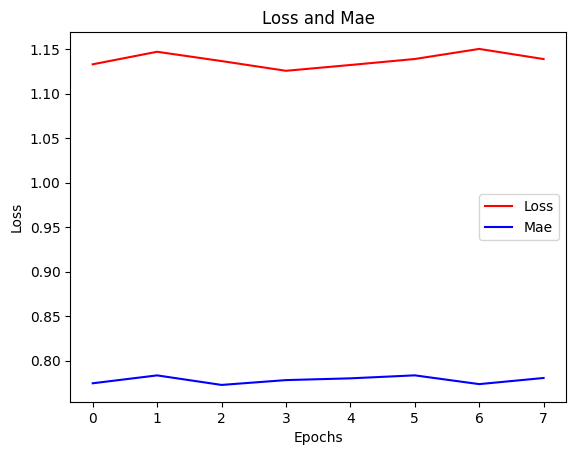

In [ ]:
# matplotlib 이용하여 그래프 그리기
# 1. plot 그리기 : 입력  history.history['loss'], 'r'
# 2. plot 그리기 : 입력  history.history['mae'], 'b'
# 3. title : 'Loss and Mae'
# 4. xlabel : "Epochs"
# 5. ylabel : "Loss"
# 6. legend : ["Loss", "Mae"]
# 7. plt.show()


plt.plot(history.history['loss'], 'r')
plt.plot(history.history['mae'], 'b')
plt.title('Loss and Mae')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Mae"])
plt.show()

<br>
<br>
<br>

---

## **5. [분류 모델] X, y 나누기**
- 지도학습 경우 데이터와 정답이 있어야 합니다.
- 데이터에 해당하는 X와 정답에 해당하는 y가 있어야 합니다.
- 아래와 같이 판다스를 이용하면 X, y를 쉽게 나눌수 있어요.
- X, y 데이터를 가지고 모델 학습하고 검증할수 있는 학습 데이터셋과 테스트 데이터셋으로 나눠 사용합니다.
- 그리고 레이블(y) 값을 보고 회귀 모델인지, 분류 모델인지 구별할수 있어요.
  - 레이블(y) : 학점 A/B/C/DF , 남녀 남/여, 숫자 0~9 --> 범주형으로 되어 있으면 분류 모델
  - 레이블(y) : 삼성전자 주가, 습도/온도, 유가동향등 --> 연속형으로 되어 있으면 회귀 모델

### **<font color=blue>우리는 분류 모델을 만들어야 하는데, 어떤 컬럼을 정답(레이블, y)를 정할까요?</font>**
### **<font color=blue>분류모델 위해서 범주형 컬럼을 레이블(y)로 선택해야 합니다.</font>**

In [ ]:
# tips2 데이터프레임의 뒤 5개 행 라인 보기
# 범주형 값들이 있는 컬럼은 무엇이 있나요?

tips2.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,1,0,1,1,3
240,27.18,2.00,0,1,1,1,2
241,22.67,2.00,1,1,1,1,2
242,17.82,1.75,1,0,1,1,2
243,18.78,3.00,0,0,3,1,2


### **<font color=blue>범주형 값을 나타내는 컬럼이 sex, smoker, day, time, size 컬럼들이 있네요</font>**

In [ ]:
# 다시 한번 tips2  앞3개 내용을 보겠습니다.

tips2.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3


### **이번엔 정답(레이블, y)을 day 컬럼으로 정했고, day의 값들이 범주형 값이니 <font color=blue>분류 모델</font>이 되겠네요.**

In [ ]:
# tips2 테이블에서 day 컬럼만 제외하면 나머지가 X가 되겠네요.
# day 컬럼만 제외한 나머지 컬럼 ['total_bill', 'tip', 'sex', 'smoker', 'time', 'size'] 조회해 봅시다.

tips2[ ['total_bill', 'tip', 'sex', 'smoker', 'time', 'size'] ]

,total_bill,tip,sex,smoker,time,size
0,16.99,1.01,0,0,1,2
1,10.34,1.66,1,0,1,3
2,21.01,3.50,1,0,1,3
3,23.68,3.31,1,0,1,2
4,24.59,3.61,0,0,1,4
...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,3
240,27.18,2.00,0,1,1,2
241,22.67,2.00,1,1,1,2
242,17.82,1.75,1,0,1,2


In [ ]:
# 레이블(y)는 tips2 테이블에서 day 컬럼만 가져오면 되겠네요.

tips2['day']

0      2
1      2
2      2
3      2
4      2
      ..
239    1
240    1
241    1
242    1
243    3
Name: day, Length: 244, dtype: int64

### **<font color=blue>판다스의 drop 함수를 이용하면 쉽게 X, y를 나눌수 있어요!!</font>**

In [ ]:
# X 데이터 분리 : 판다스 drop 함수 활용
# 입력 : 'day', axis=1

X = tips2.drop('day', axis=1)

In [ ]:
# 분리된 X 데이터 확인 : 데이터 타입이 데이터프레임 확인
# 레이블 day 컬럼은 보이지 않음을 확인할수 있습니다.

X

,total_bill,tip,sex,smoker,time,size
0,16.99,1.01,0,0,1,2
1,10.34,1.66,1,0,1,3
2,21.01,3.50,1,0,1,3
3,23.68,3.31,1,0,1,2
4,24.59,3.61,0,0,1,4
...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,3
240,27.18,2.00,0,1,1,2
241,22.67,2.00,1,1,1,2
242,17.82,1.75,1,0,1,2


In [ ]:
# y 데이터 분리 : 'day' 컬럼값만 분리

y = tips2['day']

In [ ]:
# 분리된 y 데이터 확인 : 데이터 타입이 Series 확인
# y 값이 정수 0~3번까지 범주형으로 되어 있음 확인

y

0      2
1      2
2      2
3      2
4      2
      ..
239    1
240    1
241    1
242    1
243    3
Name: day, Length: 244, dtype: int64

### **X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 볼게요.**

In [ ]:
# X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 주는 train_test_split 함수가 있습니다.
# train_test_split 함수를 이용하면 쉽게 학습 데이터셋과 테스트 데이터셋 만들수 있습니다.
# 사이킷런의 train_test_split 함수 불러 옵니다.

from sklearn.model_selection import train_test_split

In [ ]:
# ? 활용하여 도움말 보기
train_test_split?

In [ ]:
# train_test_split 함수
# 1. X ,y 입력
# 2. test_size=0.2 --> train set : test set  = 8 : 2
# 3. random_state 사용하지 않으면 실행할때마다 학습셋과 테스트셋이 다르게 나와 고정하기 위해 사용
# 4. train_test_split 함수 결과로 X_train, X_test, y_train, y_test 나옴.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
# 학습 데이터셋과 테스트 데이터셋의 사이즈 확인

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [ ]:
# 뒤쪽에서 사용하게 편하게 데이터프레임을 넘파이(numpy)로 변경합니다.

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

<br>
<br>
<br>

---

## **6.  [분류 모델] 딥러닝 모델링**

![DNMN](https://github.com/gzone1357/Image1/raw/main/img_deeplearning_09_ann.png)

---

### **1) 딥러닝 모델링 하기 위해, 제일 먼저 필요한 라이브러리 불러오기 입니다.**

In [ ]:
# 딥러닝 필요한 라이브러리 가져오기
# Sequential : 위의 전체 그림 레이아웃이라고 보시면 됩니다.
# Dense : 히든 레이어, 아웃풋 레이어을 가르키는 층으로 보시면 됩니다.
# EarlyStopping : callback으로 매 학습마다 성능을 측정하고 성능이 더 이상 나아지지 않으면 조기종료
# ModelCheckpoint : 주로 성능이 제일 좋을때 모델을 저장하는데 사용

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### **2) 전체 그림을 그릴수 있는 도화지 Sequential 정의합니다.**

In [ ]:
# 전체 그림을 그릴수 있는 도화지가 필요하듯이,
# 딥러닝 모델을 만들기 위한 Sequential 함수를 정의하여 model 이름으로 저장합니다.

model = Sequential()

### **3) 도화지를 채우기전에 입력과 출력을 고려해 봅시다.**

In [ ]:
# 입력 레이어에서 받아들여야 할 입력 갯수는 얼마일까요? X의 컬럼의 갯수만큼이 입력으로 들어가겠죠.
# 출력 레이어에서 출력으로 나가야할 갯수는 얼마일까요? 먼저 다중분류를 기억하고 , day(y) 값이 0 ,1, 2, 3 로 되어 있으며
# 우리가 아웃풋 결과값을 4로 정하면, 4개의 출력이 나오며 각 동그라미마다 0의 확률, 1의 확률, 2의 확률, 3의 확률이 출력되로록 하면 됨
# X_train.shape, np.unique(y_train) 출력해 보자

print(X_train.shape)
print(np.unique(y_train))

(195, 6)
[0 1 2 3]


### **4) 도화지에 우리가 필요한만큼의 레이어를 만들수 있으며 먼저 1개의 레이어 만들어 봅시다.**

In [ ]:
# 첫번째 레이어 즉, 첫번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 10개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 첫번째 히든 레이어는 입력을 꼭, 받아야 합니다. 몇개의 입력을 받을지 모델에게 알려 주어야 합니다.

model.add(  Dense( 10, activation='relu', input_shape=(6,)  )  )

### **5) 도화지에 1개의 레이어를 추가해 볼게요.**

In [ ]:
# 두번째 레이어 즉, 두번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 10개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 두번째 히든 레이어부터는 입력을 몇개 받을지 모델에게 알려줄 필요가 없어요. 알아서 계산하기 때문입니다.

model.add(  Dense(  10, activation='relu',  )  )

### **6) 도화지에 출력 레이어를 추가해 봅시다.**

In [ ]:
# 세번째 레이어 즉, 세번째 히든레이어(Dense Layer)로 마지막 레이어이기에 아웃풋 레이어 됩니다.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 아웃풋 레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 0부터 4까지의 각각의 확률 출력해야 하므로 4개 동그라미 출력 필요
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다.
# 다중분류 모델이고 4개의 동그라미에서 확률 결과값이 출력되므로 활성화 함수를 'softmax' 으로 지정합니다.

model.add(  Dense(  4, activation='softmax',  )  )

### **7) 도화지에서 그려진 전체 그림을 보겠습니다.**

In [ ]:
# summary() 함수를 사용해서 전체 레이아웃을 봅니다.

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 10)                70        
                                                                 
 dense_13 (Dense)            (None, 10)                110       
                                                                 
 dense_14 (Dense)            (None, 4)                 44        
                                                                 
Total params: 224
Trainable params: 224
Non-trainable params: 0
_________________________________________________________________


### **8) 도화지에서 그려진 전체 그림을 한꺼번에 그려보면**

In [ ]:
# Sequential 모델 만들기 --> model 변수 저장
# input layer : (6, )
# hidden layer : 10 unit , activation='relu'
# hidden layer : 10 unit , activation='relu'
# output layer : 4 unit , activation='softmax'

model = Sequential()
model.add(  Dense( 10, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 10, activation='relu',  )  )
model.add(  Dense( 4, activation='softmax'  )  )

### **9) 도화지에서 그려진 그림을 컴퓨터가 이해해서 성능 좋은 모델을 만들어 보겠습니다.**

In [ ]:
# 모델 컴파일 : compile > 컴퓨터가 좋은 성능의 모델이 될수 있도록 여러가지 옵션을 설정해야 합니다.
# 분류 모델 loss : 4개의 아웃풋 동그라미 이므로 'sparse_categorical_crossentropy'
# 최적화 알고리즘 : optimizer='adam'
# 모델의 성능 측정 : metrics=['accuracy']

model.compile(  loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy']  )

### **10) 도화지에 그려진 그림을 가지고 모델을 만들었으니, 학습을 진행하도록 할게요.**

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train , y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=20,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# 학습결과 저장 : history

history = model.fit(  X_train , y_train, epochs=20, batch_size=8  )

Epoch 1/20
25/25 [==============================] - 0s 1ms/step - loss: 2.6012 - accuracy: 0.2821
Epoch 2/20
25/25 [==============================] - 0s 1ms/step - loss: 1.7938 - accuracy: 0.3282
Epoch 3/20
25/25 [==============================] - 0s 1ms/step - loss: 1.4277 - accuracy: 0.3077
Epoch 4/20
25/25 [==============================] - 0s 1ms/step - loss: 1.3156 - accuracy: 0.3077
Epoch 5/20
25/25 [==============================] - 0s 1ms/step - loss: 1.3042 - accuracy: 0.3282
Epoch 6/20
25/25 [==============================] - 0s 1ms/step - loss: 1.3111 - accuracy: 0.3333
Epoch 7/20
25/25 [==============================] - 0s 1ms/step - loss: 1.2941 - accuracy: 0.3692
Epoch 8/20
25/25 [==============================] - 0s 873us/step - loss: 1.2849 - accuracy: 0.3231
Epoch 9/20
25/25 [==============================] - 0s 704us/step - loss: 1.2863 - accuracy: 0.3231
Epoch 10/20
25/25 [==============================] - 0s 1ms/step - loss: 1.2750 - accuracy: 0.3333
Epoch 11/20
25/

### **11) X_train, y_train 학습 데이터셋으로 모델 학습하고 , X_test, y_test 테스트 데이터셋으로 학습  검증합니다.**
> epochs = 50 으로 수정

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test)  )

Epoch 1/50
25/25 [==============================] - 0s 6ms/step - loss: 1.2378 - accuracy: 0.4359 - val_loss: 1.2478 - val_accuracy: 0.3469
Epoch 2/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2427 - accuracy: 0.4103 - val_loss: 1.2559 - val_accuracy: 0.3265
Epoch 3/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2280 - accuracy: 0.4359 - val_loss: 1.2305 - val_accuracy: 0.3878
Epoch 4/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2329 - accuracy: 0.4051 - val_loss: 1.2323 - val_accuracy: 0.3469
Epoch 5/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2197 - accuracy: 0.4410 - val_loss: 1.2396 - val_accuracy: 0.3469
Epoch 6/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2251 - accuracy: 0.4205 - val_loss: 1.2447 - val_accuracy: 0.4082
Epoch 7/50
25/25 [==============================] - 0s 2ms/step - loss: 1.2147 - accuracy: 0.4410 - val_loss: 1.2210 - val_accuracy: 0.3469
Epoch 8/50
25/25 [==

### **12) 모델 성능이 더 이상 좋아지지 않는데 50번씩 학습하고 있다. 조기종료와 성능 좋은 모델 저장하자.**

In [ ]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.h5', monitor='val_loss', save_best_only=True, berbose=1  )

history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 [==============================] - 0s 5ms/step - loss: 0.8796 - accuracy: 0.6564 - val_loss: 0.8135 - val_accuracy: 0.7347
Epoch 2/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8757 - accuracy: 0.6513 - val_loss: 0.7982 - val_accuracy: 0.6939
Epoch 3/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8589 - accuracy: 0.6256 - val_loss: 0.7901 - val_accuracy: 0.6939
Epoch 4/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8523 - accuracy: 0.6462 - val_loss: 0.7759 - val_accuracy: 0.6939
Epoch 5/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8443 - accuracy: 0.6513 - val_loss: 0.7676 - val_accuracy: 0.6939
Epoch 6/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8349 - accuracy: 0.6513 - val_loss: 0.7617 - val_accuracy: 0.6939
Epoch 7/50
25/25 [==============================] - 0s 3ms/step - loss: 0.8341 - accuracy: 0.6359 - val_loss: 0.7514 - val_accuracy: 0.6939
Epoch 8/50
25/25 [==

### **13) 학습된 딥러닝 모델을 가지고 tip 예측해 보도록 하겠습니다.**

In [ ]:
# 테스트 데이터의 2개의  X,  y 데이터값 확인

X_test[0:2], y_test[0:2]

(array([[19.82,  3.18,  1.  ,  0.  ,  1.  ,  2.  ],
        [ 8.77,  2.  ,  1.  ,  0.  ,  1.  ,  2.  ]]),
 array([1, 2], dtype=int64))

In [ ]:
# 0 라인 샘플 데이터을 모델 입력해서 예측하기
# rfr 모델의 predict 함수 활용
# 입력 : [X[0]], 결과 : pred 저장
# pred 결과 출력
# pred 결과에 대한 분류값 출력 : np.argmax(pred, axis=1)

pred = model.predict(X_test[0:2])
print(pred)

np.argmax(pred, axis=1)

1/1 [==============================] - 0s 46ms/step
[[0.0353641  0.44017896 0.50616604 0.01829087]
 [0.02833885 0.36999416 0.58955705 0.0121099 ]]


array([2, 2], dtype=int64)

### **14) 학습시 loss, accuracy에 대해 그래프를 그려 보겠습니다.**

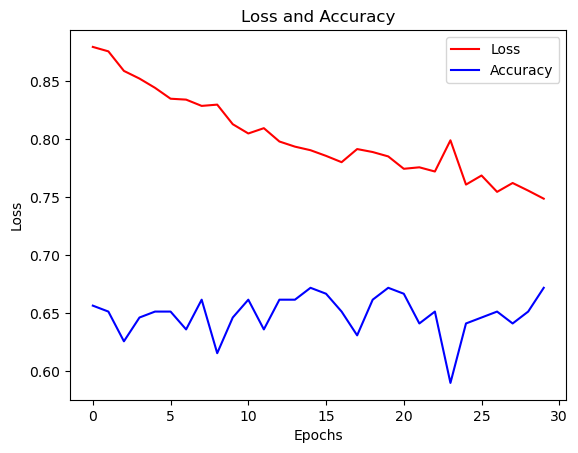

In [ ]:
# matplotlib 이용하여 그래프 그리기
# 1. plot 그리기 : 입력  history.history['loss'], 'r'
# 2. plot 그리기 : 입력  history.history['accuracy'], 'b'
# 3. title : 'Loss and Accuracy'
# 4. xlabel : "Epochs"
# 5. ylabel : "Loss"
# 6. legend : ["Loss", "Accuracy"]
# 7. plt.show()


plt.plot(history.history['loss'], 'r')
plt.plot(history.history['accuracy'], 'b')
plt.title('Loss and Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Accuracy"])
plt.show()

<br>
<br>
<br>

# **[실습] 딥러닝 모델링하기**

**아래 가이드에 따라 tips 데이터프레임을 활용하여 딥러닝 모델을 만드세요.**

- **회귀 DNN 모델 만들기**
  - 대상 데이터 : tips 데이터프레임
  - X, y 데이터 만들기
    - y 레이블 : total_bill
    - x 퓨쳐 : total_bill 제외한 나머지
  - train_test_split 함수를 활용해서 학습 데이터셋과 테스트 데이터셋을 만드세요.
    - 학습데이터셋 : 테스트데이터셋 = 8 : 2
    - random_state : 41  
  - DNN 모델을 만드세요.
    - 첫번째 히든 레이어 : 유닛 6
    - 두번째 히든 레이어 : 유닛 4
    - 아웃풋레이어 : 유닛 1, activation=None
  - DNN 모델 컴파일 및 조기종료,  최적 성능 모델 저장 그리고 학습하세요.
    - 모델 compile : loss='mse', optimizer='adam', metrics=['mse', 'mae']
    - EarlyStopping : patience=3
    - ModelCheckpoint
    - 모델 학습 fit
  - 만든 DNN 모델을 활용해서 아래 시뮬레이션 데이터에 대한 예측하세요.
    - 시뮬레이션 데이터 :  [3.23, 1.  , 0.  , 2.  , 1.  , 2.  ]

- **분류 DNN 모델 만들기**
  - 대상 데이터 : tips 데이터프레임
  - X, y 데이터 만들기
    - y 레이블 : smoker
    - x 퓨쳐 : smoker 제외한 나머지
  - train_test_split 함수를 활용해서 학습 데이터셋과 테스트 데이터셋을 만드세요.
    - 학습데이터셋 : 테스트데이터셋 = 8 : 2
    - random_state : 41  
  - DNN 모델을 만드세요.
    - 첫번째 히든 레이어 : 유닛 6
    - 두번째 히든 레이어 : 유닛 4
    - 아웃풋레이어 : 유닛 1, , activation='sigmoid'
  - DNN 모델 컴파일 및 조기종료,  최적 성능 모델 저장 그리고 학습하세요.
    - 모델 compile : loss='mse', optimizer='adam', metrics=['mse', 'mae']
    - EarlyStopping : patience=3
    - ModelCheckpoint
    - 모델 학습 fit
  - 만든 DNN 모델을 활용해서 아래 시뮬레이션 데이터에 대한 예측하세요.
    - 시뮬레이션 데이터 :  [23.33,  5.65,  1.  ,  2.  ,  1.  ,  2.  ]

**회귀 DNN 모델**

In [ ]:
# X, y 나누기
X = tips.drop('total_bill', axis=1)
y = tips[ 'total_bill' ]

In [ ]:
# 학습 데이터셋과 테스트 데이터셋 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=41 )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [ ]:
# DNN 모델 생성 및 학습
# 첫번째 히든 레이어 : 유닛 6
# 두번째 히든 레이어 : 유닛 4
# 아웃풋레이어 : 유닛 1

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sequential 모델 생성
model = Sequential()
model.add(  Dense( 6, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation=None  )  )

# 컴파일
model.compile(  loss='mse', optimizer='adam', metrics=['mse', 'mae']  )

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.h5', monitor='val_loss', save_best_only=True, berbose=1  )

# 모델 학습
history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 [==============================] - 2s 21ms/step - loss: 407.2871 - mse: 407.2871 - mae: 18.1179 - val_loss: 332.8827 - val_mse: 332.8827 - val_mae: 16.7646
Epoch 2/50
25/25 [==============================] - 0s 7ms/step - loss: 367.6036 - mse: 367.6036 - mae: 17.0756 - val_loss: 290.4840 - val_mse: 290.4840 - val_mae: 15.5600
Epoch 3/50
25/25 [==============================] - 0s 7ms/step - loss: 320.2963 - mse: 320.2963 - mae: 15.7890 - val_loss: 245.3093 - val_mse: 245.3093 - val_mae: 14.1535
Epoch 4/50
25/25 [==============================] - 0s 7ms/step - loss: 269.2036 - mse: 269.2036 - mae: 14.2386 - val_loss: 196.1628 - val_mse: 196.1628 - val_mae: 12.4384
Epoch 5/50
25/25 [==============================] - 0s 8ms/step - loss: 217.0117 - mse: 217.0117 - mae: 12.4525 - val_loss: 149.0122 - val_mse: 149.0122 - val_mae: 10.5279
Epoch 6/50
25/25 [==============================] - 0s 10ms/step - loss: 166.5539 - mse: 166.5539 - mae: 10.5571 - val_loss: 106.9979 - val

In [ ]:
# DNN 모델을 활용해서 시뮬레이션 데이터 예측하기

simul = [3.23, 1. , 0. , 2. , 1. , 2. ]
model.predict([ simul ])

1/1 [==============================] - 0s 119ms/step


array([[20.71647]], dtype=float32)

<br>

**분류 DNN 모델**

In [ ]:
# X, y 나누기
X = tips.drop('smoker', axis=1)
y = tips[ 'smoker' ]

In [ ]:
# 학습 데이터셋과 테스트 데이터셋 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=41 )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [ ]:
# DNN 모델 생성 및 학습
# 첫번째 히든 레이어 : 유닛 6
# 두번째 히든 레이어 : 유닛 4
# 아웃풋레이어 : 유닛 1

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sequential 모델 생성
model = Sequential()
model.add(  Dense( 6, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation='sigmoid'  )  )

# 컴파일
model.compile(  loss='mse', optimizer='adam', metrics=['mse', 'mae']  )

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.h5', monitor='val_loss', save_best_only=True, berbose=1  )

# 모델 학습
history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 [==============================] - 1s 17ms/step - loss: 0.3946 - mse: 0.3946 - mae: 0.5354 - val_loss: 0.3441 - val_mse: 0.3441 - val_mae: 0.5500
Epoch 2/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2473 - mse: 0.2473 - mae: 0.4765 - val_loss: 0.1964 - val_mse: 0.1964 - val_mae: 0.4273
Epoch 3/50
25/25 [==============================] - 0s 8ms/step - loss: 0.2255 - mse: 0.2255 - mae: 0.4515 - val_loss: 0.1860 - val_mse: 0.1860 - val_mae: 0.4066
Epoch 4/50
25/25 [==============================] - 0s 8ms/step - loss: 0.2259 - mse: 0.2259 - mae: 0.4564 - val_loss: 0.1940 - val_mse: 0.1940 - val_mae: 0.4228
Epoch 5/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2244 - mse: 0.2244 - mae: 0.4531 - val_loss: 0.1912 - val_mse: 0.1912 - val_mae: 0.4177
Epoch 6/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2243 - mse: 0.2243 - mae: 0.4543 - val_loss: 0.1918 - val_mse: 0.1918 - val_mae: 0.4188
Epoch 6: early stopping


In [ ]:
# DNN 모델을 활용해서 시뮬레이션 데이터 예측하기

simul = [23.33,  5.65,  1.  ,  2.  ,  1.  ,  2.  ]
model.predict([ simul ])

1/1 [==============================] - 0s 79ms/step


array([[0.6878844]], dtype=float32)

---